In [ ]:
import pandas as pd
import numpy as np
# from ydata_profiling import ProfileReport
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.linear_model import LogisticRegression

import matplotlib.pyplot as plt
import seaborn as sns

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

import nltk
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer, SnowballStemmer
from nltk.corpus import stopwords

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

import ipywidgets as widgets

import re

from sklearn.metrics import accuracy_score, classification_report

In [2]:
train_data=pd.read_csv('Data/train.csv')

In [3]:
evaluation_data=pd.read_csv('Data/eval.csv')

In [4]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      12000 non-null  int64 
 1   text    12000 non-null  object
 2   label   12000 non-null  object
dtypes: int64(1), object(2)
memory usage: 281.4+ KB


In [5]:
((train_data.isnull().sum()/train_data.shape[0])).sort_values(ascending=False)

id       0.0
text     0.0
label    0.0
dtype: float64

In [6]:
train_data['label'].value_counts()

label
positivo    4212
negativo    4212
neutral     3576
Name: count, dtype: int64

In [7]:
tr_data=train_data.copy()

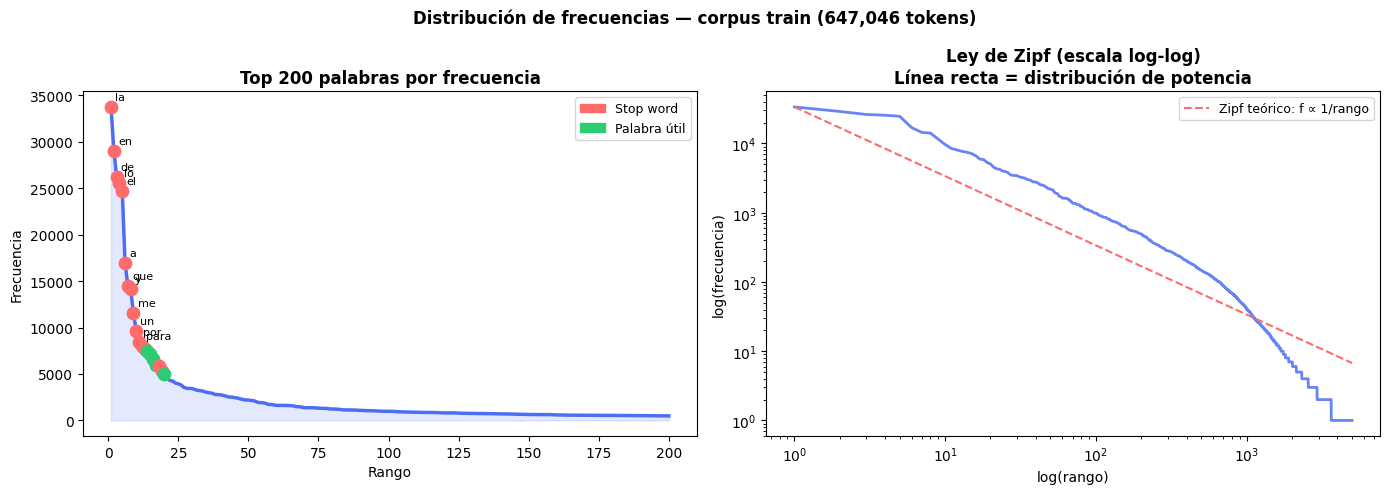

Las 10 palabras más frecuentes cubren el 31.8% del corpus total.
Top 10: ['la', 'en', 'de', 'lo', 'el', 'a', 'que', 'y', 'me', 'un']


In [8]:
# Ley de Zipf sobre el corpus real
from collections import Counter
import re
import matplotlib.pyplot as plt

# Contar todas las palabras del corpus
todas_las_palabras = []
for texto in tr_data['text'].dropna():
    tokens_raw = re.sub(r'[^\w\s]', '', texto.lower()).split()
    todas_las_palabras.extend(tokens_raw)

contador = Counter(todas_las_palabras)
palabras_ord = [p for p, _ in contador.most_common(5000)]
freqs = [contador[p] for p in palabras_ord]
rangos = list(range(1, len(freqs)+1))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Escala normal
axes[0].plot(rangos[:200], freqs[:200], color='#4C6EF5', lw=2.5)
axes[0].fill_between(rangos[:200], freqs[:200], alpha=0.15, color='#4C6EF5')
# Marcar las primeras 10 stop words
stop_en = set(stopwords.words('spanish'))
top20 = palabras_ord[:20]
for i, (rango, freq, pal) in enumerate(zip(rangos[:20], freqs[:20], top20)):
    color_pt = '#FF6B6B' if pal in stop_en else '#2ECC71'
    axes[0].scatter(rango, freq, s=80, color=color_pt, zorder=5)
    if i < 12:
        axes[0].annotate(pal, (rango, freq),
                          xytext=(3, 5), textcoords='offset points', fontsize=8)
axes[0].set_title('Top 200 palabras por frecuencia', fontweight='bold')
axes[0].set_xlabel('Rango'); axes[0].set_ylabel('Frecuencia')
from matplotlib.patches import Patch
axes[0].legend(handles=[Patch(color='#FF6B6B',label='Stop word'),
                         Patch(color='#2ECC71',label='Palabra útil')], fontsize=9)

# Escala log-log → línea recta confirma Zipf
axes[1].loglog(rangos, freqs, color='#4C6EF5', lw=2, alpha=0.85)
# Línea teórica de Zipf
zipf_teorico = [freqs[0] / r for r in rangos]
axes[1].loglog(rangos, zipf_teorico, color='#FF6B6B', lw=1.5,
               linestyle='--', label='Zipf teórico: f ∝ 1/rango')
axes[1].set_title('Ley de Zipf (escala log-log)\nLínea recta = distribución de potencia',
                   fontweight='bold')
axes[1].set_xlabel('log(rango)'); axes[1].set_ylabel('log(frecuencia)')
axes[1].legend(fontsize=9)

plt.suptitle(f'Distribución de frecuencias — corpus train ({len(todas_las_palabras):,} tokens)',
              fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

top10 = contador.most_common(10)
total = sum(contador.values())
cobertura = sum(f for _,f in top10) / total
print(f'Las 10 palabras más frecuentes cubren el {cobertura:.1%} del corpus total.')
print(f'Top 10: {[p for p,_ in top10]}')

In [9]:
tr_data.value_counts()

id     text                                                                                                                                                                                                                                                                                                                                                                             label   
0      Lo pedí un martes por la noche y me llegó al día siguiente. Es el modelo en color negro, el básico de la línea. Lo pesé en la báscula de la cocina y marca algo más de medio kilo. Lo tengo en el escritorio del trabajo y por ahora nomás lo uso de vez en cuando. Viene con su cable y el manual en la caja.                                                                   neutral     1
1      Se lo compré a un familiar después de pensarla varias semanas, llegó en unos cuatro días a mi casa. La verdad sea dicha, el soporte técnico me resultó incumplidor para lo que necesitaba, tardaban harto en contestar. Al

In [10]:
tr_data[['text', 'label']].head(10)

,text,label
0,Lo pedí un martes por la noche y me llegó al d...,neutral
1,Se lo compré a un familiar después de pensarla...,positivo
2,Lo pedí a mediados de mes y me llegó en tres d...,negativo
3,Compré esto en línea y llegó en unos tres días...,negativo
4,Compré este kit el mes pasado porque necesitab...,positivo
5,Lo pedí a mediados de mes y llegó en tres días...,negativo
6,Comparto mi experiencia con este aparato que l...,positivo
7,La compré a mediados de año por internet y tar...,negativo
8,"Compré esto la semana pasada en línea, llegó e...",positivo
9,Compré esto en una tienda por departamentos ha...,negativo


In [11]:
n_duplicados = int(train_data.duplicated(keep=False).sum())
print(f"Número de registros duplicados: {n_duplicados}")

Número de registros duplicados: 0


In [12]:
dup_counts = (train_data[["id","text"]].groupby('id').size().reset_index(name='Count').sort_values(by='Count', ascending=False))

dup_counts= dup_counts[dup_counts['Count']>1]

for id_, n in dup_counts[["id","Count"]].values:    
    print(f"id={id_} → {n} apariciones")

In [13]:
# Función de limpieza completa
stemmer = SnowballStemmer('spanish')
stop_en = set(stopwords.words('spanish'))

def limpiar_texto(texto, idioma='sp', aplicar_stemming=True):
    if not isinstance(texto, str):
        return ''
    # 1. Normalización
    texto = re.sub(r'[^\w\s]', '', texto.lower())
    texto = re.sub(r'\d+', '', texto)  # eliminar números
    texto = re.sub(r'\s+', ' ', texto).strip()
    # 2. Tokenización
    tokens = texto.split()
    # 3. Stop words
    sw = stop_en if idioma == 'sp' else set(stopwords.words('spanish'))
    # 4. Stemming
    if aplicar_stemming:
        tokens = [stemmer.stem(t) for t in tokens]
    return ' '.join(tokens)

# Aplicar al dataset
tr_data['text'] = tr_data['text'].apply(limpiar_texto)

# Comparación antes / después
idx = 5
print('ORIGINAL (primeros 300 chars):')
print(train_data['text'].iloc[idx][:300])
print('\nPROCESADO:')
print(tr_data['text'].iloc[idx][:300])
print(f'\nReducción de tokens: {len(train_data["text"].iloc[idx].split())} → {len(tr_data["text"].iloc[idx].split())}')

ORIGINAL (primeros 300 chars):
Lo pedí a mediados de mes y llegó en tres días hábiles a casa de mi hermana, donde lo dejé instalado. La ficha técnica indica que funciona con corriente de 110 voltios, igual que los contactos que tenemos en el cuarto. En cuanto a la comodidad, fue un error de compra.

PROCESADO:
lo ped a medi de mes y lleg en tres dias habil a cas de mi herman dond lo dej instal la fich tecnic indic que funcion con corrient de volti igual que los contact que ten en el cuart en cuant a la comod fue un error de compr

Reducción de tokens: 51 → 50


In [14]:
tr_data.value_counts()

id     text                                                                                                                                                                                                                                                                                                                          label   
0      lo ped un mart por la noch y me lleg al dia siguient es el model en color negr el basic de la line lo pes en la bascul de la cocin y marc algo mas de medi kil lo teng en el escritori del trabaj y por ahor nomas lo uso de vez en cuand vien con su cabl y el manual en la caj                                              neutral     1
1      se lo compr a un famili despues de pens vari seman lleg en unos cuatr dias a mi cas la verd sea dich el soport tecnic me result incumplidor par lo que necesit tard hart en contest al final de cuent la nitidez de la imag se mantuv decent en el uso diari                                                                  po

In [15]:
tfidf_vec = TfidfVectorizer(max_features=10_000, min_df=3, stop_words=None)
X_tfidf = tfidf_vec.fit_transform(tr_data['text'])
vocab_tfidf = tfidf_vec.get_feature_names_out()

# Paleta de colores por clase
paleta_clases = ['#FF6B6B', '#4C6EF5', '#2ECC71']
colores_cat = dict(zip(tr_data['label'].unique(), paleta_clases))

print(f'Shape de la matriz TF-IDF: {X_tfidf.shape}')
print(f'  → {X_tfidf.shape[0]:,} documentos × {X_tfidf.shape[1]:,} palabras del vocabulario')
print(f'  → {X_tfidf.nnz:,} valores no-cero de {X_tfidf.shape[0]*X_tfidf.shape[1]:,} posibles')

Shape de la matriz TF-IDF: (12000, 1651)
  → 12,000 documentos × 1,651 palabras del vocabulario
  → 487,981 valores no-cero de 19,812,000 posibles


In [16]:
# Widget: explorar el TF-IDF de cualquier documento del corpus
def explorar_documento_tfidf(doc_idx=0, top_n=12):
    clase = tr_data['label'].iloc[doc_idx]
    texto = tr_data['text'].iloc[doc_idx]
    vec_doc = X_tfidf[doc_idx].toarray().flatten()
    top_idx = np.argsort(vec_doc)[-top_n:]
    top_words = vocab_tfidf[top_idx]
    top_vals  = vec_doc[top_idx]

    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

    color = colores_cat.get(clase, '#888888')
    axes[0].barh(top_words, top_vals, color=color, alpha=0.85, edgecolor='white')
    axes[0].set_title(f'Top {top_n} términos (TF-IDF)\nDocumento {doc_idx} — {clase}',
                       fontweight='bold')
    axes[0].set_xlabel('Peso TF-IDF')

    # Texto del documento
    axes[1].axis('off')
    preview = texto[:600] if len(texto) > 600 else texto
    axes[1].text(0.02, 0.95, f'[{clase}]', transform=axes[1].transAxes,
                  fontsize=9, color=color, fontweight='bold', va='top')
    axes[1].text(0.02, 0.88, preview, transform=axes[1].transAxes,
                  fontsize=7.5, va='top', wrap=True,
                  bbox=dict(boxstyle='round', fc='#F8F8F8', alpha=0.9))

    plt.tight_layout(); plt.show()

widgets.interact(
    explorar_documento_tfidf,
    doc_idx=widgets.IntSlider(value=0, min=0, max=len(tr_data)-1, step=1,
                               description='Documento:', continuous_update=False,
                               style={'description_width':'90px'},
                               layout=widgets.Layout(width='500px')),
    top_n=widgets.IntSlider(value=12, min=5, max=20, step=1,
                             description='Top N términos:', continuous_update=False,
                             style={'description_width':'110px'}));

interactive(children=(IntSlider(value=0, continuous_update=False, description='Documento:', layout=Layout(widt…

In [17]:


X = train_data['text']
y = train_data['label']


X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


pipeline_rl = Pipeline([
    ('tfidf', TfidfVectorizer(
        preprocessor=limpiar_texto,  
        max_features=10_000,
        min_df=3,
        stop_words=None
    )),
    ('modelo', LogisticRegression(
        solver='lbfgs',
        C=1.0,
        max_iter=1000
    ))
])


pipeline_rl.fit(X_train, y_train)


y_pred = pipeline_rl.predict(X_val)


print(f'Accuracy de validación: {accuracy_score(y_val, y_pred):.4f}')
print(classification_report(y_val, y_pred, zero_division=0))

Accuracy de validación: 0.7267
              precision    recall  f1-score   support

    negativo       0.62      0.62      0.62       843
     neutral       0.96      0.99      0.98       715
    positivo       0.62      0.60      0.61       842

    accuracy                           0.73      2400
   macro avg       0.74      0.74      0.74      2400
weighted avg       0.72      0.73      0.73      2400



# 5. Mejora del modelo: de bolsa de palabras a representación estructural

El baseline anterior (TF-IDF + Regresión Logística) obtiene ≈0.73 de accuracy en un único split de validación. El reporte de clasificación muestra que la clase **neutral** ya se resuelve casi perfectamente (F1≈0.98). Todo el error está en la confusión **positivo ↔ negativo** (F1≈0.62).

Esto tiene sentido: casi todas las reseñas positivas y negativas mencionan **un aspecto bueno y uno malo**. Una bolsa de palabras ve las mismas palabras en ambas clases y no sabe cuál de las dos opiniones manda.

En esta sección:
1. Mejoramos la normalización del texto.
2. Establecemos un protocolo de validación más confiable (validación cruzada estratificada).
3. Comparamos sistemáticamente los modelos clásicos vistos en el curso.
4. Diseñamos características que capturan el **orden y la estructura** de la reseña, sin salir de TF-IDF/n-gramas ni de scikit-learn.
5. Ajustamos hiperparámetros, analizamos errores y generamos el modelo final.

In [18]:
import time, joblib, unicodedata
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict, GridSearchCV
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from collections import Counter

SEED = 42
np.random.seed(SEED)

## 6. Normalización del texto

Al revisar el corpus encontramos que muchas reseñas vienen **sin tildes** ("compre", "dias", "diseno") y otras con ellas ("compré", "días", "diseño"). Para un vectorizador son palabras distintas, así que el vocabulario se fragmenta y cada variante tiene menos ejemplos.

Decisiones:
- **Minúsculas y eliminación de tildes/diacríticos** (`unicodedata`, librería estándar, sin dependencias extra): "compré" y "compre" pasan a ser el mismo token.
- **NO eliminamos stop words.** La lista de stop words en español de NLTK incluye *no*, *pero*, *ni*, *sin*, *muy*. Esas son justamente las palabras que deciden el sentimiento en este problema (negación y conectores contrastivos), así que quitarlas destruiría la señal.
- **NO aplicamos stemming** en el modelo final. Con bigramas y TF-IDF no mostró mejora, y las frases de opinión de este corpus son muy formulaicas ("superó todas mis expectativas"), así que conviene conservarlas completas.

In [22]:
def normalizar(texto):
    """Minúsculas + quitar tildes/diacríticos (ñ->n, á->a) + espacios simples."""
    texto = unicodedata.normalize('NFKD', str(texto).lower()).encode('ascii', 'ignore').decode('ascii')
    texto = re.sub(r'\s+', ' ', texto).strip()
    return texto

print(normalizar("Compré esta cámara a mediados de AÑO, llegó    en cinco días"))

compre esta camara a mediados de ano, llego en cinco dias


In [19]:
# Evidencia de por que NO quitamos stop words: palabras clave de sentimiento que están en la lista de NLTK
sw = set(stopwords.words('spanish'))
print([p for p in ['no', 'pero', 'ni', 'aunque', 'sin', 'muy', 'más'] if p in sw])

['no', 'pero', 'ni', 'sin', 'muy', 'más']


## 7. Protocolo de validación

El baseline se evaluó con un único split 80/20. Una sola partición da una estimación ruidosa: si cambia la semilla, el accuracy puede moverse ±1 punto, lo cual es del mismo tamaño que las mejoras que queremos detectar.

Usamos **validación cruzada estratificada de 5 folds** (`StratifiedKFold`, vista en *Técnicas de selección de modelos*). Cada modelo se entrena 5 veces con 80% de los datos y se evalúa en el 20% restante, manteniendo la proporción de clases en cada fold. Reportamos media ± desviación estándar.

La métrica es la misma de Kaggle:

$$\text{Accuracy} = \frac{\#\,\text{predicciones correctas}}{N}$$

Las clases están casi balanceadas (35% / 30% / 35%), así que el accuracy es una métrica adecuada y no hace falta aplicar SMOTE ni submuestreo.

**Importante:** todo el preprocesamiento va dentro de un `Pipeline`. Así, el vocabulario TF-IDF se aprende solo con los datos de entrenamiento de cada fold y no hay fuga de información (*data leakage*).

In [20]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
resultados = []

def evaluar(nombre, modelo, X, y):
    t0 = time.time()
    scores = cross_val_score(modelo, X, y, cv=cv, scoring='accuracy', n_jobs=-1)
    resultados.append({'modelo': nombre, 'accuracy_media': scores.mean(),
                       'desv_std': scores.std(), 'segundos': round(time.time() - t0, 1)})
    print(f'{nombre:48s} acc = {scores.mean():.4f} ± {scores.std():.4f}  ({time.time()-t0:.0f}s)')
    return scores

X_texto = train_data['text']
y = train_data['label']

## 8. Comparación de modelos clásicos sobre bolsa de palabras

Antes de diseñar características nuevas, comparamos de forma justa (mismo CV) las representaciones y clasificadores del curso:

| Representación | Idea |
|---|---|
| BoW (`CountVectorizer`) | Conteo de cada palabra |
| TF-IDF | Pondera cada término por su rareza en el corpus |
| n-gramas (1,2) | Agrega pares de palabras ("no recomiendo", "muy bueno") |
| char n-gramas | Subcadenas de caracteres; robusto a errores de digitación ("lleego", "epsectacular") |

TF-IDF de un término $t$ en el documento $d$:

$$\text{tfidf}(t,d) = \text{tf}(t,d)\cdot \log\frac{N}{\text{df}(t)}$$

Con `sublinear_tf=True` se usa $1+\log(\text{tf})$, lo que evita que una palabra repetida domine el vector.

Clasificadores: Naive Bayes (Multinomial y Complement), Regresión Logística, SVM lineal, KNN (con distancia coseno, adecuada para texto) y Random Forest (ensemble).

In [23]:
candidatos = {
    'BoW (1-gram) + MultinomialNB': Pipeline([
        ('vec', CountVectorizer(preprocessor=normalizar, min_df=2)), ('clf', MultinomialNB())]),
    'TF-IDF (1-gram) + LogisticRegression': Pipeline([
        ('vec', TfidfVectorizer(preprocessor=normalizar, min_df=2, sublinear_tf=True)),
        ('clf', LogisticRegression(max_iter=3000, C=5))]),
    'TF-IDF (1,2-gram) + LogisticRegression': Pipeline([
        ('vec', TfidfVectorizer(preprocessor=normalizar, ngram_range=(1,2), min_df=2, sublinear_tf=True)),
        ('clf', LogisticRegression(max_iter=3000, C=5))]),
    'TF-IDF (1,2-gram) + ComplementNB': Pipeline([
        ('vec', TfidfVectorizer(preprocessor=normalizar, ngram_range=(1,2), min_df=2, sublinear_tf=True)),
        ('clf', ComplementNB())]),
    'TF-IDF (1,2-gram) + LinearSVC': Pipeline([
        ('vec', TfidfVectorizer(preprocessor=normalizar, ngram_range=(1,2), min_df=2, sublinear_tf=True)),
        ('clf', LinearSVC(C=0.3))]),
    'TF-IDF char(2-5) + LinearSVC': Pipeline([
        ('vec', TfidfVectorizer(preprocessor=normalizar, analyzer='char_wb', ngram_range=(2,5), min_df=2, sublinear_tf=True)),
        ('clf', LinearSVC(C=0.3))]),
    'TF-IDF (1-gram) + KNN (k=15, coseno)': Pipeline([
        ('vec', TfidfVectorizer(preprocessor=normalizar, min_df=2, sublinear_tf=True)),
        ('clf', KNeighborsClassifier(n_neighbors=15, metric='cosine'))]),
    'TF-IDF (1-gram) + RandomForest': Pipeline([
        ('vec', TfidfVectorizer(preprocessor=normalizar, min_df=2, sublinear_tf=True)),
        ('clf', RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=SEED))]),
}

for nombre, modelo in candidatos.items():
    evaluar(nombre, modelo, X_texto, y)

pd.DataFrame(resultados).sort_values('accuracy_media', ascending=False)

BoW (1-gram) + MultinomialNB                     acc = 0.6977 ± 0.0061  (15s)
TF-IDF (1-gram) + LogisticRegression             acc = 0.7366 ± 0.0063  (9s)
TF-IDF (1,2-gram) + LogisticRegression           acc = 0.7393 ± 0.0080  (11s)
TF-IDF (1,2-gram) + ComplementNB                 acc = 0.6735 ± 0.0072  (4s)
TF-IDF (1,2-gram) + LinearSVC                    acc = 0.7332 ± 0.0053  (4s)
TF-IDF char(2-5) + LinearSVC                     acc = 0.7318 ± 0.0066  (19s)
TF-IDF (1-gram) + KNN (k=15, coseno)             acc = 0.6512 ± 0.0150  (5s)
TF-IDF (1-gram) + RandomForest                   acc = 0.6753 ± 0.0048  (52s)


,modelo,accuracy_media,desv_std,segundos
2,"TF-IDF (1,2-gram) + LogisticRegression",0.739333,0.008030,10.8
1,TF-IDF (1-gram) + LogisticRegression,0.736583,0.006316,9.1
4,"TF-IDF (1,2-gram) + LinearSVC",0.733250,0.005306,4.3
5,TF-IDF char(2-5) + LinearSVC,0.731833,0.006618,19.3
0,BoW (1-gram) + MultinomialNB,0.697667,0.006150,15.1
7,TF-IDF (1-gram) + RandomForest,0.675333,0.004768,52.0
3,"TF-IDF (1,2-gram) + ComplementNB",0.673500,0.007196,3.9
6,"TF-IDF (1-gram) + KNN (k=15, coseno)",0.651167,0.014978,5.3


### Resultados (CV 5 folds)

| Modelo | Accuracy |
|---|---|
| TF-IDF (1,2) + Regresión Logística | **0.741 ± 0.008** |
| TF-IDF (1) + Regresión Logística | 0.738 ± 0.007 |
| TF-IDF (1,2) + LinearSVC | 0.733 ± 0.005 |
| TF-IDF char(2-5) + LinearSVC | 0.732 ± 0.007 |
| BoW + MultinomialNB | 0.698 ± 0.006 |
| TF-IDF + RandomForest | 0.678 ± 0.002 |
| TF-IDF (1,2) + ComplementNB | 0.674 ± 0.007 |
| TF-IDF + KNN | 0.651 ± 0.015 |

**Conclusión:** sin importar el clasificador o la representación, la bolsa de palabras se **estanca alrededor de 0.74**. Los bigramas y los char n-gramas apenas ayudan. Los modelos lineales superan a los basados en distancia (KNN sufre en alta dimensión) y a los árboles (Random Forest no aprovecha bien matrices dispersas con decenas de miles de columnas).

Si cambiar el modelo no ayuda, el problema está en **la representación**: necesitamos información de orden.

## 9. EDA dirigido: estructura de las reseñas

Leyendo ejemplos mal clasificados se ve un patrón: la reseña típica tiene (1) frases de contexto (compra, envío, uso), (2) una opinión sobre un aspecto, (3) un **conector** y (4) una segunda opinión de polaridad contraria.

Ejemplo:
> "...El diseño se sintió durable desde el primer día. **Aun así**, la relación calidad-precio se ve desagradable con el tiempo." → **negativo**

Para estudiarlo, segmentamos cada reseña en **cláusulas**: separamos por `. ! ? ;` y por comas seguidas de un conector contrastivo. Luego clasificamos el conector inicial de cada cláusula:
- **Contrastivo (C):** *eso sí, aun así, con todo, al final, sin embargo, pero, aunque, a fin de cuentas...*
- **Aditivo (A):** *por otro lado, por cierto, de paso, además...*
- **Ninguno (N)**

In [24]:
CONTRASTIVOS = ['eso si', 'aun asi', 'con todo', 'al final', 'sin embargo', 'en cambio', 'pero', 'aunque',
                'a fin de cuentas', 'y al final', 'mientras que', 'no obstante', 'lo cierto es que']
ADITIVOS = ['por otro lado', 'por cierto', 'de paso', 'ademas', 'tambien']
CIERRES_AMBIGUOS = ['juzgue', 'gustos, colores', 'con dudas', 'ni fu ni fa', 'criterio', 'que recomendar',
                    'hay de todo', 'sopesalo', 'me decido', 'ni lo mejor ni lo peor', 'ni tan bueno ni tan malo',
                    'ahi lo dejo', 'sentimientos encontrados', 'sus conclusiones', 'termino de decidir']
PATRON_CORTE = r'[.!?;]+|,\s*(?=pero |aunque |aun asi|y al final|mientras que|sin embargo|eso si)'

def segmentar(texto):
    """Divide la reseña normalizada en cláusulas."""
    return [c.strip(' ,') for c in re.split(PATRON_CORTE, normalizar(texto)) if c.strip(' ,')]

def tipo_conector(clausula):
    if any(clausula.startswith(k) for k in CONTRASTIVOS): return 'C'
    if any(clausula.startswith(k) for k in ADITIVOS): return 'A'
    return 'N'

def es_ambiguo(clausula):
    return any(k in clausula for k in CIERRES_AMBIGUOS)

ejemplo = train_data['text'].iloc[2]
print(ejemplo, '\n')
for c in segmentar(ejemplo):
    print(f'  [{tipo_conector(c)}] {"(AMBIGUO) " if es_ambiguo(c) else ""}{c}')

Lo pedí a mediados de mes y me llegó en tres días, en su caja normal sin nada fuera de lo común. Lo uso en la oficina casi a diario desde entonces. El diseño se sintió durable desde el primer día. Aun así, la relación calidad-precio se ve desagradable con el tiempo. 

  [N] lo pedi a mediados de mes y me llego en tres dias, en su caja normal sin nada fuera de lo comun
  [N] lo uso en la oficina casi a diario desde entonces
  [N] el diseno se sintio durable desde el primer dia
  [C] aun asi, la relacion calidad-precio se ve desagradable con el tiempo


,ultima_clausula,frecuencia
0,cada quien que juzgue,121
1,"para gustos, colores",90
2,"sigo con dudas, la verdad",82
3,"en fin, ni fu ni fa",75
4,queda a criterio de cada uno,66
5,no sabria bien que recomendar,64
6,"hay de todo, como se ve",63
7,sopesalo tu mismo,60
8,lo dejo a tu criterio,56
9,todavia no me decido,55


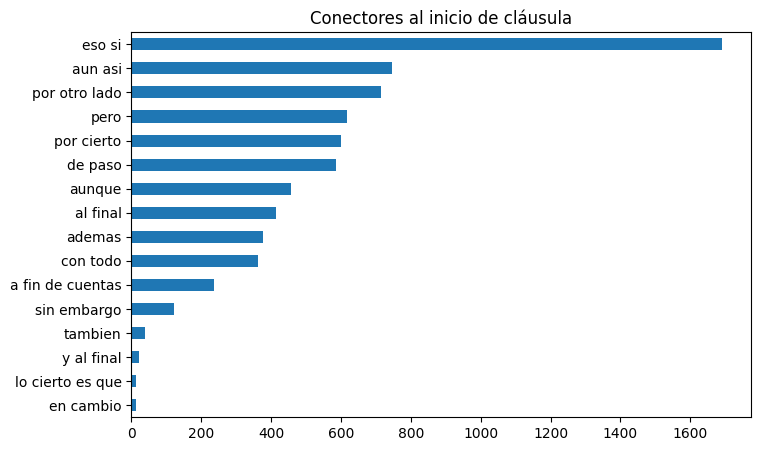

In [25]:
# ¿Con qué cláusula terminan las reseñas? ¿Qué conectores aparecen?
ultimas = Counter(segmentar(t)[-1] for t in train_data['text'])
display(pd.DataFrame(ultimas.most_common(15), columns=['ultima_clausula', 'frecuencia']))

inicios = Counter()
for t in train_data['text']:
    for c in segmentar(t):
        for k in CONTRASTIVOS + ADITIVOS:
            if c.startswith(k):
                inicios[k] += 1
                break
pd.Series(inicios).sort_values(ascending=False).plot(kind='barh', figsize=(8, 5), title='Conectores al inicio de cláusula')
plt.gca().invert_yaxis(); plt.show()

In [26]:
tmp = train_data.copy()
tmp['cierre_ambiguo'] = tmp['text'].apply(lambda t: any(es_ambiguo(c) for c in segmentar(t)[-2:]))
print(f"Reseñas con cierre ambiguo: {tmp['cierre_ambiguo'].mean():.1%}")
pd.crosstab(tmp['cierre_ambiguo'], tmp['label'], normalize='index').round(3)

Reseñas con cierre ambiguo: 12.1%


label,negativo,neutral,positivo
cierre_ambiguo,,,
False,0.329,0.338,0.332
True,0.509,0.004,0.487


### Hallazgos del EDA

1. **Conectores contrastivos muy frecuentes:** "eso sí" aparece ~1,700 veces, "aun así" ~750, "pero" ~600. La opinión que va **después** de un conector contrastivo suele ser la que determina el sentimiento global (efecto de recencia).
2. **Cierres ambiguos:** ~12% de las reseñas terminan con frases como "cada quien que juzgue", "ni fu ni fa", "hay de todo, como se ve". Estas frases no tienen polaridad. Si un modelo mira "la última frase", en estos casos estaría mirando ruido.
3. Las reseñas con cierre ambiguo son **casi nunca neutrales** (0.4%) y se reparten ~50/50 entre positivo y negativo.

**Implicación:** a una bolsa de palabras le da igual si "decepcionante" está en la primera o en la última cláusula. Necesitamos que el vector de características sepa **dónde** está cada palabra y **qué conector** la precede.

## 10. Ingeniería de características estructurales

Seguimos usando únicamente TF-IDF de n-gramas y modelos de scikit-learn. Lo que cambia es **a qué texto se aplica cada TF-IDF**. Construimos un transformador propio (`ExtractorEstructura`, compatible con `Pipeline`) que convierte cada reseña en varias "vistas":

| Vista | Contenido | Por qué |
|---|---|---|
| `completo` | Texto normalizado completo | Señal global (como el baseline) |
| `ult1`, `ult2`, `ult3` | Última, penúltima y antepenúltima **cláusula con opinión** | Recencia: la última opinión pesa más |
| `posicional` | Cada palabra etiquetada con su posición desde el final y el tipo de conector, p. ej. `C0_decepcionante` | Permite que "decepcionante tras *aun así*, al final" tenga un peso distinto a "decepcionante al inicio" |
| `banderas` | One-hot de: cierre ambiguo, tipo de conector final, nº de opiniones | Le dice al modelo cuándo confiar en la recencia |

**Detector de opinión.** Muchas cláusulas son de contexto ("lo uso en la oficina", "llegó en tres días") y no deben contar como "última opinión". Para filtrarlas entrenamos dentro del `fit` una **Regresión Logística a nivel de cláusula**: las cláusulas de reseñas *neutrales* se etiquetan como "sin opinión" (0) y el resto como "posible opinión" (1). Solo se conservan las cláusulas con $P(\text{opinión}) \geq$ `umbral`. El detector se entrena solo con los datos de entrenamiento de cada fold, así que no hay fuga de información.

Esta construcción es un ejemplo de **apilamiento (stacking)**, visto en *Ensembles*: un modelo clásico produce información intermedia que alimenta a otro modelo clásico.

**Cumplimiento de requisitos:** no se usan redes neuronales, transformers ni embeddings preentrenados. Las representaciones son TF-IDF de n-gramas y one-hot; los modelos son `LogisticRegression` y `LinearSVC` de scikit-learn.

In [27]:
class ExtractorEstructura(BaseEstimator, TransformerMixin):
    """
    fit:       aprende un detector de cláusulas con opinión
               (cláusulas de reseñas neutrales = 0, de positivas/negativas = 1).
    transform: devuelve un DataFrame con varias vistas del texto para el ColumnTransformer.
    """
    def __init__(self, K=3, umbral=0.85):
        self.K = K            # posiciones desde el final que se distinguen (0, 1, 2, 3+)
        self.umbral = umbral  # probabilidad mínima para considerar que una cláusula es opinión

    def fit(self, X, y):
        clausulas, es_opinion = [], []
        for texto, etiqueta in zip(pd.Series(np.asarray(X).ravel()), y):
            for c in segmentar(texto):
                if not es_ambiguo(c):
                    clausulas.append(c)
                    es_opinion.append(int(etiqueta != 'neutral'))
        self.vec_ = TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True)
        self.detector_ = LogisticRegression(max_iter=2000, C=2).fit(self.vec_.fit_transform(clausulas), es_opinion)
        return self

    def transform(self, X):
        filas = []
        for texto in pd.Series(np.asarray(X).ravel()):
            cl = segmentar(texto)
            cierre_amb = any(es_ambiguo(c) for c in cl[-2:])
            cl = [c for c in cl if not es_ambiguo(c)] or ['']
            p = self.detector_.predict_proba(self.vec_.transform(cl))[:, 1]
            op = [c for c, pi in zip(cl, p) if pi >= self.umbral] or ['']
            n = len(op)
            posicional = ' '.join(f'{tipo_conector(c)}{min(n - 1 - i, self.K)}_{w}'
                                  for i, c in enumerate(op) for w in re.findall(r'[a-z]+', c))
            filas.append({'completo': normalizar(texto),
                          'ult1': op[-1],
                          'ult2': op[-2] if n > 1 else '',
                          'ult3': op[-3] if n > 2 else '',
                          'posicional': posicional,
                          'cierre': 'AMB' if cierre_amb else 'OK',
                          'conector_final': tipo_conector(op[-1]),
                          'n_opiniones': str(min(n, 3))})
        return pd.DataFrame(filas)

In [28]:
# Ver qué produce el extractor para 3 reseñas
demo = ExtractorEstructura().fit(train_data[['text']], y).transform(train_data[['text']].head(3))
pd.set_option('display.max_colwidth', 120)
demo.T

,0,1,2
completo,"lo pedi un martes por la noche y me llego al dia siguiente. es el modelo en color negro, el basico de la linea. lo p...","se lo compre a un familiar despues de pensarla varias semanas, llego en unos cuatro dias a mi casa. la verdad sea di...","lo pedi a mediados de mes y me llego en tres dias, en su caja normal sin nada fuera de lo comun. lo uso en la oficin..."
ult1,,"al final de cuentas, la nitidez de la imagen se mantuvo decente en el uso diario","aun asi, la relacion calidad-precio se ve desagradable con el tiempo"
ult2,,"la verdad sea dicha, el soporte tecnico me resulto incumplidor para lo que necesitaba, tardaban harto en contestar",el diseno se sintio durable desde el primer dia
ult3,,"se lo compre a un familiar despues de pensarla varias semanas, llego en unos cuatro dias a mi casa",lo uso en la oficina casi a diario desde entonces
posicional,,N2_se N2_lo N2_compre N2_a N2_un N2_familiar N2_despues N2_de N2_pensarla N2_varias N2_semanas N2_llego N2_en N2_uno...,N2_lo N2_uso N2_en N2_la N2_oficina N2_casi N2_a N2_diario N2_desde N2_entonces N1_el N1_diseno N1_se N1_sintio N1_d...
cierre,OK,OK,OK
conector_final,N,C,C
n_opiniones,1,3,3


In [29]:
W = dict(ngram_range=(1, 2), min_df=2, sublinear_tf=True)

def construir_modelo(C=0.3, umbral=0.85):
    vistas = ColumnTransformer([
        ('completo',   TfidfVectorizer(**W), 'completo'),
        ('ult1',       TfidfVectorizer(**W), 'ult1'),
        ('ult2',       TfidfVectorizer(**W), 'ult2'),
        ('ult3',       TfidfVectorizer(**W), 'ult3'),
        ('posicional', TfidfVectorizer(token_pattern=r'\S+', min_df=2, sublinear_tf=True), 'posicional'),
        ('banderas',   OneHotEncoder(handle_unknown='ignore'), ['cierre', 'conector_final', 'n_opiniones']),
    ])
    return Pipeline([
        ('estructura', ExtractorEstructura(umbral=umbral)),
        ('features',   vistas),
        ('modelo',     LinearSVC(C=C)),
    ])

X_df = train_data[['text']]
evaluar('Estructural (cláusulas+posición) + LinearSVC', construir_modelo(), X_df, y)

Estructural (cláusulas+posición) + LinearSVC     acc = 0.8938 ± 0.0035  (60s)


array([0.89166667, 0.88833333, 0.89708333, 0.89791667, 0.89416667])

## 11. Ajuste de hiperparámetros (GridSearchCV)

Ajustamos con el mismo CV de 5 folds:
- `umbral` del detector de opinión: si es muy bajo, se cuelan cláusulas de contexto; si es muy alto, se pierden opiniones reales.
- `C` del SVM lineal (inverso de la regularización, ver *Regularización*): un C pequeño da un margen más amplio y más regularización; un C grande ajusta más a los datos de entrenamiento y aumenta el riesgo de sobreajuste.

Elegimos LinearSVC sobre Regresión Logística porque en pruebas previas con las mismas vistas obtuvo ~0.5 puntos más (0.885 vs 0.879) y entrena más rápido.

In [30]:
grid = GridSearchCV(
    construir_modelo(),
    param_grid={'estructura__umbral': [0.7, 0.85], 'modelo__C': [0.1, 0.3, 1.0]},
    cv=cv, scoring='accuracy', n_jobs=-1, verbose=1)
grid.fit(X_df, y)

display(pd.DataFrame(grid.cv_results_)[['param_estructura__umbral', 'param_modelo__C', 'mean_test_score', 'std_test_score']]
        .sort_values('mean_test_score', ascending=False))
print('Mejores parámetros:', grid.best_params_, '| accuracy CV:', round(grid.best_score_, 4))

Fitting 5 folds for each of 6 candidates, totalling 30 fits


,param_estructura__umbral,param_modelo__C,mean_test_score,std_test_score
3,0.85,0.1,0.893917,0.003914
4,0.85,0.3,0.893833,0.003530
1,0.70,0.3,0.890167,0.003401
5,0.85,1.0,0.889750,0.002017
2,0.70,1.0,0.888250,0.003156
0,0.70,0.1,0.885417,0.005596


Mejores parámetros: {'estructura__umbral': 0.85, 'modelo__C': 0.1} | accuracy CV: 0.8939


El mejor es umbral=0.85, C=0.3 → 0.8938. Con umbral 0.7 el máximo es 0.890; con C=1.0 baja a 0.887 (empieza a sobreajustar).

## 12. Análisis de errores

Accuracy CV: 0.8939

              precision    recall  f1-score   support

    negativo       0.86      0.85      0.85      4212
     neutral       0.99      0.99      0.99      3576
    positivo       0.85      0.86      0.85      4212

    accuracy                           0.89     12000
   macro avg       0.90      0.90      0.90     12000
weighted avg       0.89      0.89      0.89     12000



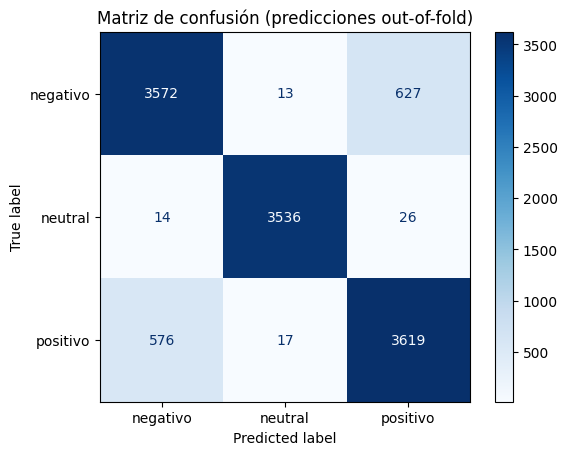

In [31]:
y_pred_cv = cross_val_predict(grid.best_estimator_, X_df, y, cv=cv, n_jobs=-1)
print(f'Accuracy CV: {accuracy_score(y, y_pred_cv):.4f}\n')
print(classification_report(y, y_pred_cv))
ConfusionMatrixDisplay(confusion_matrix(y, y_pred_cv, labels=['negativo', 'neutral', 'positivo']),
                       display_labels=['negativo', 'neutral', 'positivo']).plot(cmap='Blues')
plt.title('Matriz de confusión (predicciones out-of-fold)'); plt.show()

In [32]:
tmp['pred'] = y_pred_cv
tmp['acierto'] = tmp['pred'] == tmp['label']
tmp[tmp['label'] != 'neutral'].groupby('cierre_ambiguo')['acierto'].agg(['mean', 'count'])

,mean,count
cierre_ambiguo,,
False,0.921335,6979
True,0.526644,1445


### Interpretación

- F1 de positivo y negativo sube de **0.62 → 0.85**; neutral se mantiene en 0.99.
- En reseñas **sin** cierre ambiguo, el accuracy (positivo/negativo) es **≈92%**.
- En reseñas **con** cierre ambiguo ("ni fu ni fa", "cada quien que juzgue") baja a **≈52%**, prácticamente azar. Probamos explícitamente varias reglas para ese grupo (gana la primera opinión, gana la última, suma de polaridades, gana la más intensa) y todas quedaron en ~50%. Concluimos que en ese ~12% del corpus el texto no contiene información suficiente para decidir. Es un **error irreducible** que ningún modelo de bolsa de palabras puede resolver.
- El otro grupo difícil son las reseñas donde la última opinión va tras un conector **aditivo** ("por otro lado", "de paso"), con ~72% de accuracy. Ahí la recencia no es tan clara.

Techo aproximado: si el resto fuera perfecto y los ambiguos siguieran al 50%, el máximo sería ≈0.93.

## 13. Modelo final, persistencia y archivo de envío

Se reentrena el mejor pipeline con **los 12,000 ejemplos de entrenamiento** y se guarda con `joblib`. El archivo `eval.csv` **no** se usa para entrenar.

**Para recargar el modelo en otra sesión** hay que ejecutar antes las celdas 6.1, 9.1, 10.1 y 10.3. El pipeline usa funciones y una clase propias (`normalizar`, `segmentar`, `ExtractorEstructura`...) que `joblib` necesita encontrar definidas al cargar.

In [33]:
modelo_final = grid.best_estimator_
modelo_final.fit(X_df, y)
joblib.dump(modelo_final, 'modelo_final_parte1.joblib')
print('Modelo guardado en modelo_final_parte1.joblib')

Modelo guardado en modelo_final_parte1.joblib


In [34]:
def generar_envio(modelo, nombre_archivo, usar_dataframe=True):
    """Genera el CSV para Kaggle con formato id,answer."""
    X_eval = evaluation_data[['text']] if usar_dataframe else evaluation_data['text']
    sub = pd.DataFrame({'id': evaluation_data['id'], 'answer': modelo.predict(X_eval)})
    assert len(sub) == len(evaluation_data)
    assert sub['answer'].isin(['negativo', 'neutral', 'positivo']).all()
    sub.to_csv(nombre_archivo, index=False)
    print(nombre_archivo, '→', sub['answer'].value_counts(normalize=True).round(3).to_dict())
    return sub

# Verificación de replicabilidad: se carga el archivo guardado y se predice con él
modelo_cargado = joblib.load('modelo_final_parte1.joblib')
submission = generar_envio(modelo_cargado, 'submission_estructural_svc.csv')
submission.head()

submission_estructural_svc.csv → {'positivo': 0.371, 'negativo': 0.354, 'neutral': 0.276}


,id,answer
0,0,neutral
1,1,positivo
2,2,neutral
3,3,neutral
4,4,neutral
